# Статистика плей-офф NBA 2010-2024:

Разведочный анализ реального датасета box scores плей-офф NBA за 14 сезонов (с 2010-11 по 2023-24).
Каждая строка - статистика **одного игрока в одной игре**: очки, подборы, передачи, броски, минуты и т.д.

**Вопросы исследования:**
1. Кто доминировал в плей-офф за эти 14 сезонов?
2. Как распределена результативность игроков за игру?
3. Дошла ли 'трехочковая революция' до плей-офф?
4. Какие показатели box-score связаны между собой?
5. Как минуты на площадке влияют на кол-во набранных очков?

**Данные:** `data/play_off_box_scores_2010_2024.csv`
**Стек:** `pandas`, `numpy`, `seaborn`, `matplotlib`.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
import os
os.makedirs("charts", exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.titlesize"] = 14
pd.set_option("display.max_columns", None)

Saving play_off_box_scores_2010_2024.csv to play_off_box_scores_2010_2024 (4).csv


## 1. Первичный осмотр данных

In [49]:
df = pd.read_csv("play_off_box_scores_2010_2024.csv")
print("Размер:", df.shape)
print("Сезоны:", df["season_year"].min(), "-", df["season_year"].max())
print("Уникальных игроков:", df["personName"].nunique(), "| команд:", df["teamName"].nunique())
df[["season_year", "personName", "teamTricode", "minutes", "points", "reboundsTotal", "assists"]].head()

Размер: (31185, 33)
Сезоны: 2010-11 - 2023-24
Уникальных игроков: 1024 | команд: 31


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,season_year,personName,teamTricode,minutes,points,reboundsTotal,assists
0,2011-12,Juwan Howard,MIA,NaN,0,0,0
1,2011-12,Juwan Howard,MIA,0:28,0,0,0
2,2010-11,Juwan Howard,MIA,6:25,1,1,1
3,2011-12,Juwan Howard,MIA,5:12,0,0,0
4,2011-12,Juwan Howard,MIA,NaN,0,0,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31185 entries, 0 to 31184
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   season_year              31185 non-null  object 
 1   game_date                31185 non-null  object 
 2   gameId                   31185 non-null  int64  
 3   teamId                   31185 non-null  int64  
 4   teamCity                 31185 non-null  object 
 5   teamName                 31185 non-null  object 
 6   teamTricode              31185 non-null  object 
 7   teamSlug                 31185 non-null  object 
 8   personId                 31185 non-null  int64  
 9   personName               31185 non-null  object 
 10  position                 11810 non-null  object 
 11  comment                  6283 non-null   object 
 12  jerseyNum                0 non-null      float64
 13  minutes                  24902 non-null  object 
 14  fieldGoalsMade        

Видно 2 проблемы: столбец `minutes` - это **текст вида `"MM:SS"`**, и есть строки, где игрок не выходил на площадку - DNP

## 2. Очистка данных

In [51]:
#Перевожу минуты "MM:SS" в число
def parse_minutes(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    if ":" in s:
        m, sec = s.split(":")[:2]
        return int(m) + float(sec)/60
    try:
        return float(s)
    except ValueError:
        return np.nan

df["minutes_played"] = df["minutes"].apply(parse_minutes)
df[["minutes", "minutes_played"]].dropna().head()

,minutes,minutes_played
1,0:28,0.466667
2,6:25,6.416667
3,5:12,5.200000
5,7:37,7.616667
16,3:31,3.516667


In [52]:
#DNP?
print("Всего строк:", len(df))
print("Строк без минут (DNP / не выходил):", df["minutes_played"].isna().sum())
print("\nПричины (топ 5):")
print(df["comment"].value_counts().head())

Всего строк: 31185
Строк без минут (DNP / не выходил): 6283

Причины (топ 5):
comment
DNP - Coach's Decision     6061
DND - Injury/Illness         78
DNP - Injury/Illness         34
NWT - League Suspension      11
NWT - NBA Suspension         11
Name: count, dtype: int64


In [53]:
#Убираю всех, кто DNP
played = df[df["minutes_played"].notna() & (df["minutes_played"] > 0)].copy()
print(f"После фильтрации: {len(played)} строк (было {len(df)})")
print(f"Удалено DNP строк: {len(df) - len(played)}")

После фильтрации: 24892 строк (было 31185)
Удалено DNP строк: 6293


## 3. Топ 10 плэй-офф игроков

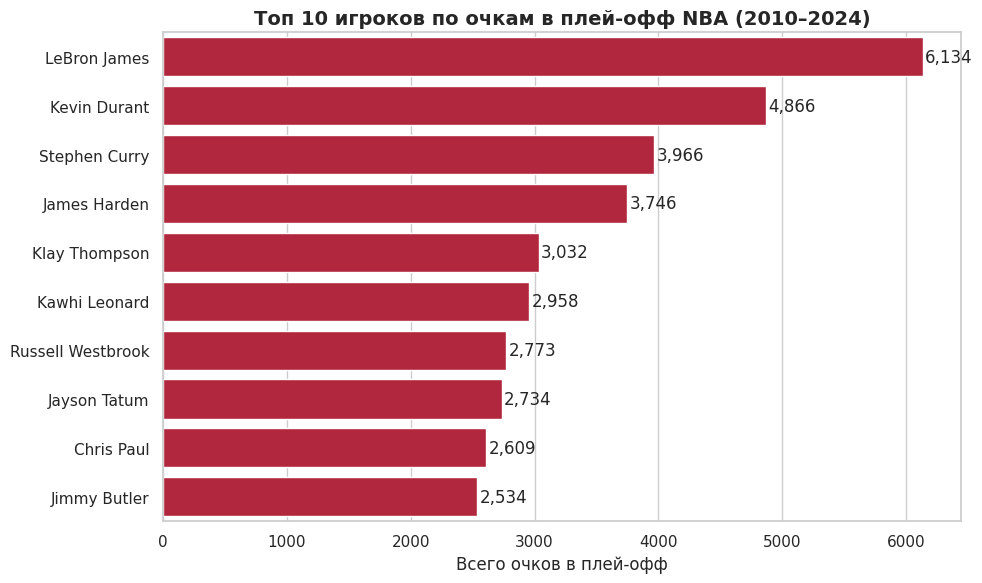

In [54]:
top_scorers = (played.groupby("personName")["points"]
                     .sum()
                     .sort_values(ascending=False)
                     .head(10))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, color="#C8102E", ax=ax)
ax.set_title("Топ 10 игроков по очкам в плей-офф NBA (2010–2024)", fontweight="bold")
ax.set_xlabel("Всего очков в плей-офф"); ax.set_ylabel("")
for i, v in enumerate(top_scorers.values):
    ax.text(v + 20, i, f"{v:,}", va="center")
plt.tight_layout(); plt.savefig("charts/chart1_top_scorers.png", dpi=130); plt.show()

**Вывод:** комментарии излишни, легенды баскетбола в топе

## 4. Лучшие по очкам за игру (PPG)

In [55]:
#Считаю игры, очки на игрока, затеа также среднее за игру (30+ игр)
player_stats = played.groupby("personName").agg(
    games=("gameId", "nunique"),
    total_points=("points", "sum"),
    total_minutes=("minutes_played", "sum"),
)
player_stats["ppg"] = (player_stats["total_points"] / player_stats["games"]).round(1)

top_ppg = (player_stats[player_stats["games"] >= 30]
           .sort_values("ppg", ascending=False)
           .head(10)[["games", "total_points", "ppg"]])
top_ppg

,games,total_points,ppg
personName,,,
Luka Doncic,50,1579,31.6
Kevin Durant,164,4866,29.7
Donovan Mitchell,54,1570,29.1
LeBron James,216,6134,28.4
Nikola Jokic,80,2272,28.4
Devin Booker,47,1333,28.4
Anthony Davis,60,1630,27.2
Stephen Curry,147,3966,27.0
Giannis Antetokounmpo,79,2105,26.6


**Вывод:** при отборе по среднему за игру (30+ игр) в топ выходят пиковые скореры плей-офф. При этом, по сравнению с прошлым графиком можно заметить, что рейтинг отличается. Это показывает, что на вопрос - 'кто лучший скорер?'- можно ответить по разному в зависимости от метрики: сумма зависит от долголетия в лучшей лиге мира, а среднее - от пиковой формы.

## 5. Как распределены очки за игру

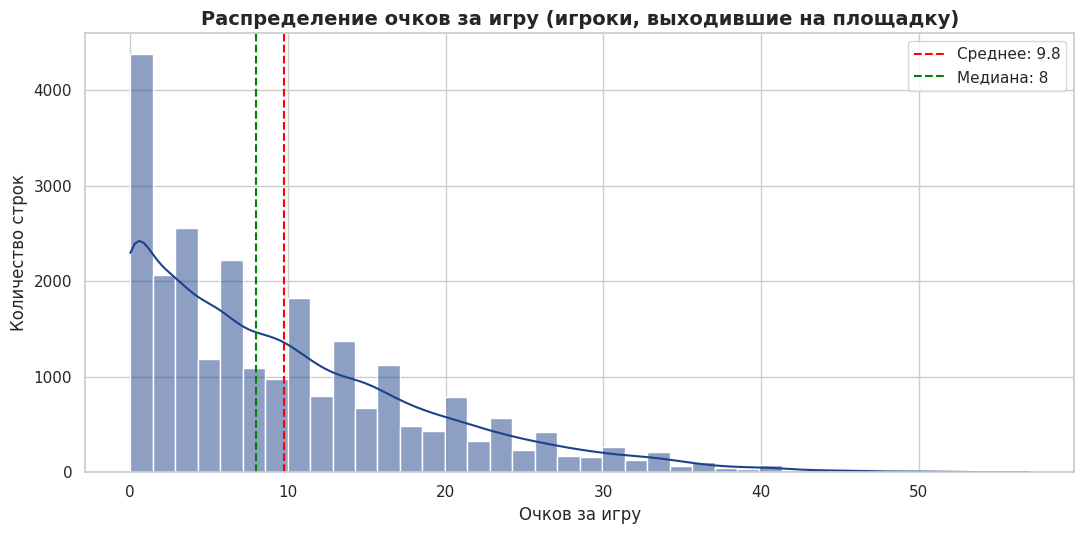

In [56]:
fig, ax = plt.subplots()
sns.histplot(played["points"], bins=40, kde=True, color="#1D428A", ax=ax)
ax.axvline(played["points"].mean(), color="red", linestyle="--",
           label=f"Среднее: {played['points'].mean():.1f}")
ax.axvline(played["points"].median(), color="green", linestyle="--",
           label=f"Медиана: {played['points'].median():.0f}")
ax.set_title("Распределение очков за игру (игроки, выходившие на площадку)", fontweight="bold")
ax.set_xlabel("Очков за игру"); ax.set_ylabel("Количество строк")
ax.legend()
plt.tight_layout(); plt.savefig("charts/chart2_points_distribution.png", dpi=130); plt.show()

**Вывод:** распределение сильно скошено вправо: большинство игроков набирают мало, а небольшая группа звёзд тянет значения вверх. Это типичная картина для спортивной статистики и хороший пример, почему **медиана честнее среднего** на скошенных данных.

## 6. Дошла ли "трёхочковая революция" до плей-офф?

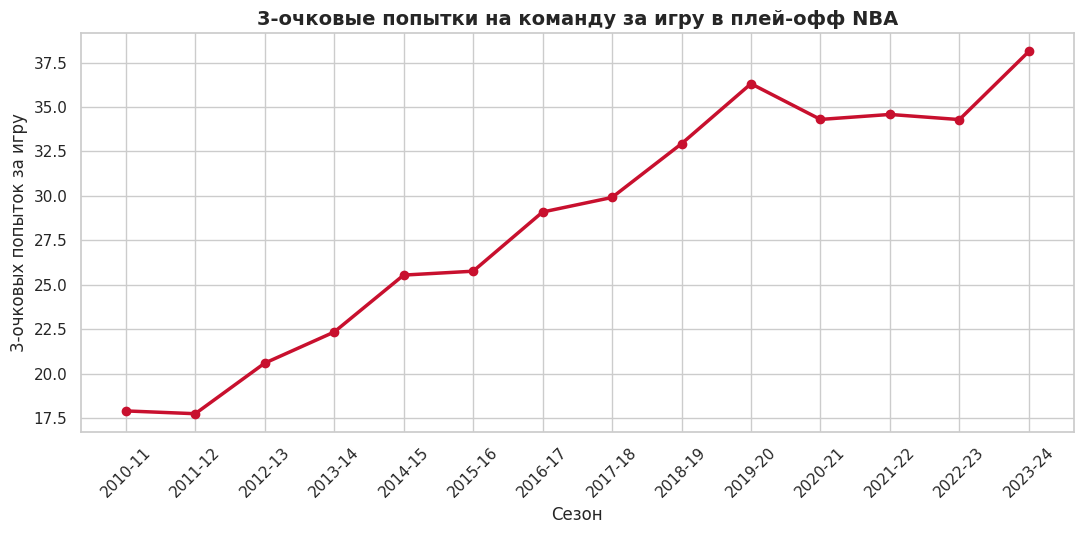

In [57]:
#Сначала суммирую 3-очковые попытки на команду в каждой игре, потом усредняю по сезонам и получаю "3PA на команду за игру".
team_game = (played.groupby(["season_year", "gameId", "teamId"])["threePointersAttempted"]
                   .sum()
                   .reset_index())
season_3pa = team_game.groupby("season_year")["threePointersAttempted"].mean()

fig, ax = plt.subplots()
ax.plot(season_3pa.index, season_3pa.values, marker="o", color="#C8102E", linewidth=2.5)
ax.set_title("3-очковые попытки на команду за игру в плей-офф NBA", fontweight="bold")
ax.set_xlabel("Сезон"); ax.set_ylabel("3-очковых попыток за игру")
plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig("charts/chart3_playoff_3pa_trend.png", dpi=130); plt.show()

**Вывод:** да, тот же тренд, что и в регулярных сезонах. Число дальних бросков в плей-офф за 14 лет выросло примерно вдвое.

## 7. Какие показатели связаны между собой

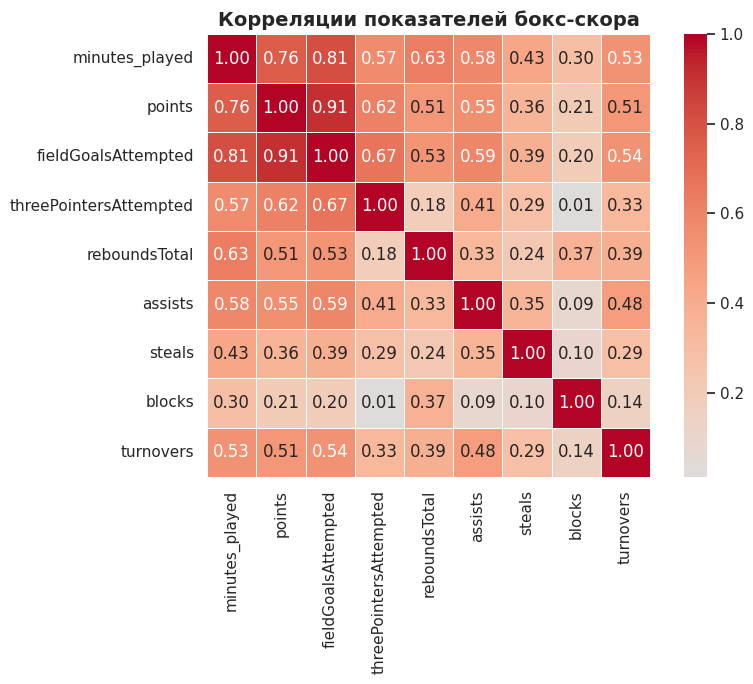

In [58]:
#Матрица корреляций основных показателей бокс-скора
stat_cols = ["minutes_played", "points", "fieldGoalsAttempted", "threePointersAttempted",
             "reboundsTotal", "assists", "steals", "blocks", "turnovers"]
corr = played[stat_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Корреляции показателей бокс-скора", fontweight="bold")
plt.tight_layout(); plt.savefig("charts/chart4_corr_heatmap.png", dpi=130); plt.show()

**Вывод:** минуты на площадке сильно связаны почти со всеми показателями. Среди самих действий заметнее всего связаны очки с попытками бросков и потери с передачами.

## 8. Минуты и очки: больше времени = больше очков?

Корреляция минут и очков: 0.76


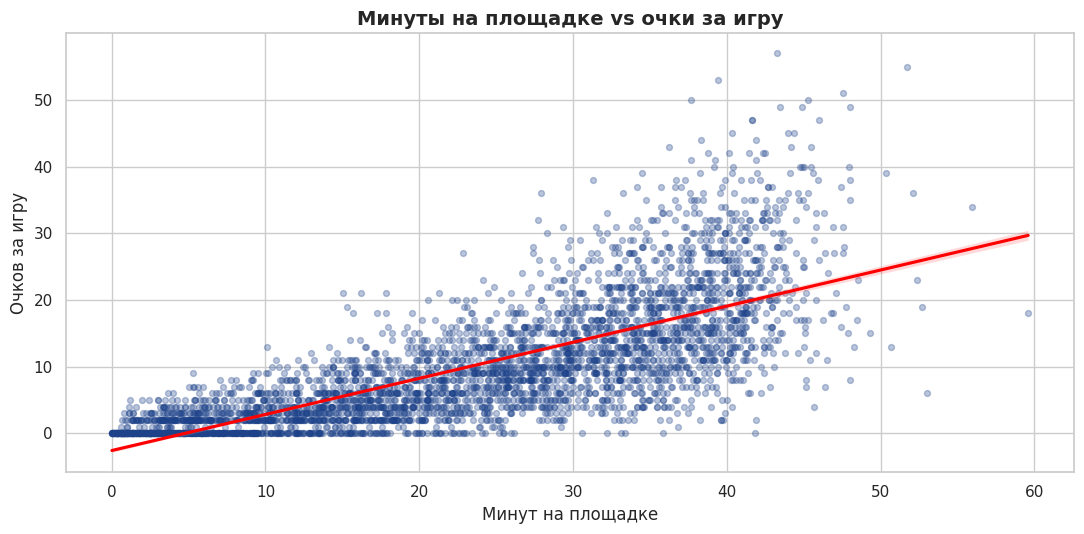

In [59]:
sample = played.sample(4000, random_state=1)
corr_mp = played["minutes_played"].corr(played["points"])
print(f"Корреляция минут и очков: {corr_mp:.2f}")

fig, ax = plt.subplots()
sns.regplot(data=sample, x="minutes_played", y="points",
            scatter_kws={"alpha": 0.3, "s": 18, "color": "#1D428A"},
            line_kws={"color": "red"}, ax=ax)
ax.set_title("Минуты на площадке vs очки за игру", fontweight="bold")
ax.set_xlabel("Минут на площадке"); ax.set_ylabel("Очков за игру")
plt.tight_layout(); plt.savefig("charts/chart5_minutes_vs_points.png", dpi=130); plt.show()

**Вывод:** связь положительная и довольно сильная, но с большим разбросом: при равных минутах одни набирают много, другие почти ничего. Минуты задают  некий потолок, а реализуют его игроки по-разному, здесь и видна разница между звездами и обычными игроками.

## 9. Лучшие отдельные матчи (топ 10 по очкам в одной игре)

In [60]:
best_games = (played.sort_values("points", ascending=False)
                    .head(10)[["personName", "season_year", "teamTricode",
                               "points", "reboundsTotal", "assists", "minutes_played"]]
                    .reset_index(drop=True))
best_games["minutes_played"] = best_games["minutes_played"].round(0)
best_games

,personName,season_year,teamTricode,points,reboundsTotal,assists,minutes_played
0,Donovan Mitchell,2019-20,UTA,57,9,7,43.0
1,Jimmy Butler,2022-23,MIA,56,9,2,41.0
2,Damian Lillard,2020-21,POR,55,6,10,52.0
3,Isaiah Thomas,2016-17,BOS,53,4,4,45.0
4,Nikola Jokic,2022-23,DEN,53,4,11,39.0
5,Jayson Tatum,2022-23,BOS,51,13,5,42.0
6,Russell Westbrook,2016-17,OKC,51,10,13,41.0
7,Donovan Mitchell,2019-20,UTA,51,4,7,38.0
8,LeBron James,2017-18,CLE,51,8,8,48.0
9,Jamal Murray,2019-20,DEN,50,5,6,43.0


**Вывод:** самые яркие индивидуальные перформансы плей-офф - это 50+ очков за матч.